In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm
from matplotlib.patches import Rectangle


import statsmodels.stats.power as smp
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

fingers = ['1', '2', '3', '4', '5'] #mapping of fingers to numbers

iti = 1000 # msecs for inter-trial interval
planTime = 2000 # msecs for precue time
feedbackTime = 2000 # msecs for feedback time

total_sub_num = 10
num_sessions = 4
num_blocks_first_session = 4
num_blocks_second_session = 4
num_blocks_third_session = 4
num_blocks_fourth_session = 4
num_trials_per_block = 120
num_trials_baseline = 20

sub_nums = [2, 3, 4, 5]

utils.set_figure_style("1col")
sns.color_palette('colorblind')



[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [2]:
# reload utils
import importlib
importlib.reload(utils)

<module 'utils' from '/Users/amin/projects/LearningDynamics/ChordAdaptationDynamics/Version3/utils.py'>

In [3]:
subjs_list = utils.read_dat_files_subjs_list(sub_nums)

subjs = pd.concat(subjs_list, ignore_index=True)

subjs['TotalTrialNum'] = ((subjs['BN']-1)//2) * (num_trials_per_block + num_trials_baseline) + (subjs['BN']-1)%2 * num_trials_baseline + subjs['TN']
session_edges = np.cumsum([num_blocks_first_session, num_blocks_second_session, num_blocks_third_session, num_blocks_fourth_session])
subjs['day'] = np.searchsorted(session_edges, subjs['BN'], side = 'left') + 1
subjs['chord'] = subjs.apply(utils.extract_chord_form_target_force, axis=1)
subjs['block_type'] = subjs.apply(utils.extract_block_type, axis=1)
subjs['trial_num_within_chord'] = subjs.apply(utils.extract_trial_num_within_chord, axis=1)
subjs['count'] = 1


subjs['num_targets'] = subjs[[f'targetForce{i}' for i in range(1, 6)]].ne(0).sum(axis=1)
subjs.reset_index(drop=True, inplace=True)

In [4]:
subjs

,BN,TN,subNum,targetForce1,targetForce2,targetForce3,targetForce4,targetForce5,endForce1,endForce2,...,forceGain,trialCorr,trialErrorType,TotalTrialNum,day,chord,block_type,trial_num_within_chord,count,num_targets
0,1,1,2,0.0,-2.0,0.0,0.0,0.0,-6.277439e+66,-6.277439e+66,...,1.0,0,1,1,1,-v---,unpurturbed,1,1,1
1,1,2,2,0.0,-2.0,0.0,0.0,0.0,-6.277439e+66,-6.277439e+66,...,1.0,0,1,2,1,-v---,unpurturbed,2,1,1
2,1,3,2,0.0,-2.0,0.0,0.0,0.0,-6.277439e+66,-6.277439e+66,...,1.0,0,2,3,1,-v---,unpurturbed,3,1,1
3,1,4,2,0.0,-2.0,0.0,0.0,0.0,-6.277439e+66,-6.277439e+66,...,1.0,0,1,4,1,-v---,unpurturbed,4,1,1
4,1,5,2,0.0,-2.0,0.0,0.0,0.0,-1.090000e-01,-1.372000e+00,...,1.0,1,0,5,1,-v---,unpurturbed,5,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4475,16,116,5,0.0,2.0,0.0,2.0,0.0,-2.150000e-01,8.720000e-01,...,1.0,1,0,1116,4,-^-^-,purturbed,136,1,2
4476,16,117,5,0.0,2.0,0.0,2.0,0.0,-1.290000e-01,2.020000e+00,...,1.0,1,0,1117,4,-^-^-,purturbed,137,1,2
4477,16,118,5,0.0,2.0,0.0,2.0,0.0,-1.640000e-01,1.085000e+00,...,1.0,1,0,1118,4,-^-^-,purturbed,138,1,2
4478,16,119,5,0.0,2.0,0.0,2.0,0.0,-3.920000e-01,1.265000e+00,...,1.0,1,0,1119,4,-^-^-,purturbed,139,1,2


# Mov Files

In [5]:
import glob
import os
def movload(fname):
    # loads .mov files given the path of the file. The .mov files have a specific custom hence the need for a custom function
    with open(fname, 'rb') as fid:
        raw = fid.read()
    if b'\x00' in raw:
        print(f'WARNING: null bytes in {fname}, truncating at first null byte')
        raw = raw[:raw.index(b'\x00')]
    text = raw.decode('utf-8', errors='replace')

    A = []
    num_columns = None
    trial = 0
    skipped = 0
    for line in text.splitlines():
        if not line:
            continue
        if line[0] == 'T':
            a = int(line.split()[1])
            trial += 1
            if a != trial:
                print('Trials out of sequence')
                trial = a
            A.append([])
            num_columns = None
        else:
            lineData = [x for x in line.strip().split('\t') if x != '']
            try:
                values = [float(x) for x in lineData]
            except ValueError:
                skipped += 1
                continue
            if num_columns is None:
                num_columns = len(values)
                A[trial - 1] = np.empty((0, num_columns))
            elif len(values) != num_columns:
                skipped += 1
                continue
            a = np.array(values, ndmin=2)
            A[trial - 1] = np.vstack((A[trial - 1], a))

    if skipped:
        print(f'WARNING: skipped {skipped} corrupt line(s) in {fname}')
    return A
pattern = utils.path +  "_*_*.mov"
files = glob.glob(pattern)
dfs = []
for file in files:
    filename = os.path.basename(file)

    parts = filename.split('_')

    if len(parts) >= 5:
        subnum = int(parts[4])
        block_number = int(parts[5].replace('.mov', ''))
        
        if subnum not in sub_nums:
            continue
        print(subnum, block_number)

        trials = movload(file)
        for trial_idx, trial in enumerate(trials):
            df = pd.DataFrame(trial, columns=['state',
                                              'timeReal', 'time',
                                              'ext1', 'ext2', 'ext3', 'ext4', 'ext5', 
                                              'flx1', 'flx2', 'flx3', 'flx4', 'flx5'])
            df['TN'] = trial_idx + 1
            df['BN'] = block_number
            df['subNum'] = subnum
            for finger in fingers:
                df[f'force{finger}'] = np.round(df[f'ext{finger}'] - df[f'flx{finger}'], 2)
            dfs.append(df)
        

dfs = pd.concat(dfs)


subjs_force = dfs.merge(subjs, on = ['subNum' , 'BN', 'TN'], how='inner')[['state', 'time', 'subNum',
                                                                           'BN','TN', 'trialCorr', 'trialErrorType',
                                                                           'targetForce1', 'targetForce2', 'targetForce3', 'targetForce4', 'targetForce5',
                                                                           'endForce1', 'endForce2', 'endForce3', 'endForce4', 'endForce5',
                                                                           'trial_num_within_chord', 'chord', 'block_type', 'num_targets',
                                                                           'TotalTrialNum'] + [f'force{finger}' for finger in fingers]]

4 7
4 13
4 12
4 6
4 10
4 4
4 5
4 11
4 15
4 1
3 8
3 9
4 14
4 2
4 16
4 3
2 5
2 11
2 10
2 4
2 12
2 6
2 7
2 13
2 3
2 2
2 16
5 9
2 14
2 15
2 1
5 8
5 11
5 5
5 4
5 10
5 6
5 12
5 13
5 7
5 3
5 16
5 2
5 14
2 9
5 1
2 8
5 15
3 13
3 7
3 6
3 12
3 4
3 10
3 11
3 5
3 1
4 8
3 15
3 14
4 9
3 16
3 2
3 3


In [ ]:
# ## --- plotting time real increments in the data ----

# diffs = []
# # df_filtered = dfs[(dfs['SubNum'] == 1) & (dfs['BN'] == 10) & (dfs['TN'] == 1)]
# for sub, subdata in dfs.groupby(['SubNum']):
#     for block, blockdata in subdata.groupby(['BN']):
#         for trial, trialdata in blockdata.groupby(['TN']):
#             # diffs = np.append(diffs, trialdata['timeReal'].diff())
#             diffs.extend(trialdata['timeReal'].diff().dropna())

# diffs = np.array(diffs)
# # diffs = diffs[(diffs > 0) & (diffs < 100)]
# # print(diffs.shape)
# # print(diffs)
# # print(sorted(diffs)[:10])
# # print(sorted(diffs)[-10:])

# # 95 and 5 percentile
# lower_bound = np.percentile(diffs, 1)
# upper_bound = np.percentile(diffs, 99)
# print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

# diffs = diffs[(diffs > lower_bound) & (diffs < upper_bound)]


# plt.hist(diffs, bins=100)
# # print(sorted(diffs)[-100:])
# # print(sorted(diffs)[:100])
# plt.show()

# # df_filtered = dfs[(dfs['SubNum'] == 1) & (dfs['BN'] == 10) & (dfs['TN'] == 1)]
# for sub, subdata in dfs.groupby(['SubNum']):
#     for block, blockdata in subdata.groupby(['BN']):
#         for trial, trialdata in blockdata.groupby(['TN']):
#             # diffs = np.append(diffs, trialdata['timeReal'].diff())
#             diffs = trialdata['timeReal'].diff()
#             # return index of diffs greater than 10 if any
#             if diffs[diffs > 10].any():
#                 print("****************")
#                 print(f"SubNum: {sub}, BN: {block}, TN: {trial}")
#                 print(trialdata[diffs > 10])
#                 print(diffs[diffs > 10])

In [8]:
import importlib
importlib.reload(utils)

/Users/amin/projects/LearningDynamics/ChordAdaptationDynamics/Version3/utils.py:181: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  subj_melted['N'] = (subj_melted['IPI_Number'].str.extract('(\d+)').astype('int64') + 1)
/Users/amin/projects/LearningDynamics/ChordAdaptationDynamics/Version3/utils.py:200: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  subj_melted['N'] = subj_melted['Press_Number'].str.extract('(\d+)').astype('int64')
/Users/amin/projects/LearningDynamics/ChordAdaptationDynamics/Version3/utils.py:215: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  subj_melted['N'] = subj_melted['Response_Number'].str.extract('(\d+)').astype('int64')


<module 'utils' from '/Users/amin/projects/LearningDynamics/ChordAdaptationDynamics/Version3/utils.py'>

In [9]:
subjs_force_train = utils.finger_melt_Forces(subjs_force)

In [11]:
def plot_forces(subjs_forces, sub_num, trial_num):
    plt.figure(figsize=(10,3))
    x = subjs_forces[(subjs_forces['subNum'] == sub_num) & (subjs_forces['TotalTrialNum'] == trial_num)]
    
    for i, (force, data) in enumerate(x.groupby('Force_Number')):
        plt.plot(data['time'], data['Force_Value'], label = force,
                 color = sns.color_palette('colorblind')[i], alpha = 0.5)
    
    
    plt.axvline(2400, color = 'black', linestyle = '--', alpha = 0.5) # go cue 
    plt.axvline(2900, color = 'black', linestyle = '--', alpha = 0.5) # sampling time


    target_cols = [f"targetForce{finger}" for finger in fingers]
    target_vals = x[target_cols].iloc[0].to_numpy(dtype=float)


    ax = plt.gca()

    rec_height = 0.5
    for finger in fingers:
        ax.add_patch(Rectangle((2900 - 95, target_vals[int(finger)-1]- (rec_height/2)), 
                            180, rec_height, color = sns.color_palette('colorblind')[int(finger)-1],alpha=0.5))


    plt.title(f'Subject {sub_num}, Trial {trial_num}')
    plt.legend()
    sns.despine(trim = True)

    plt.show()
    

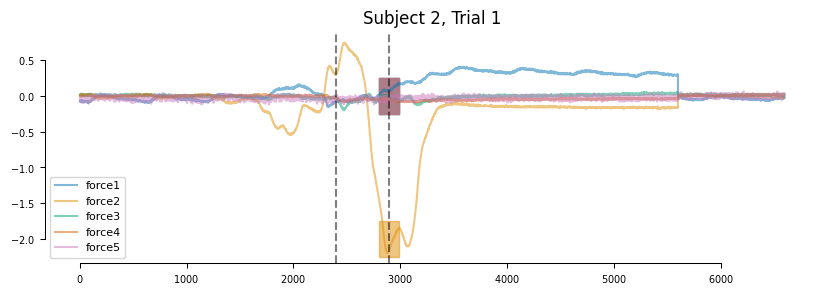

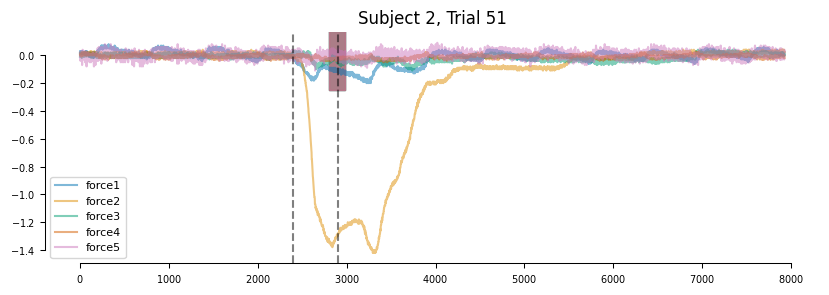

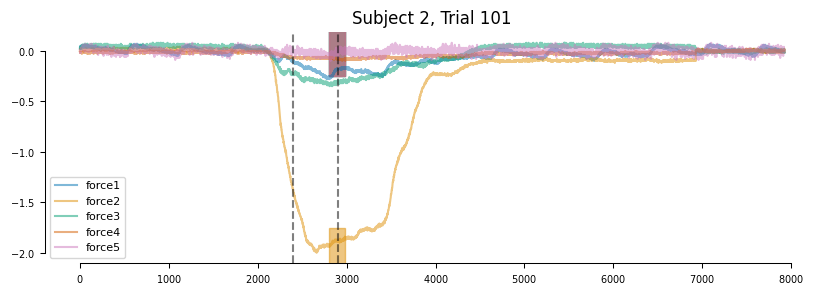

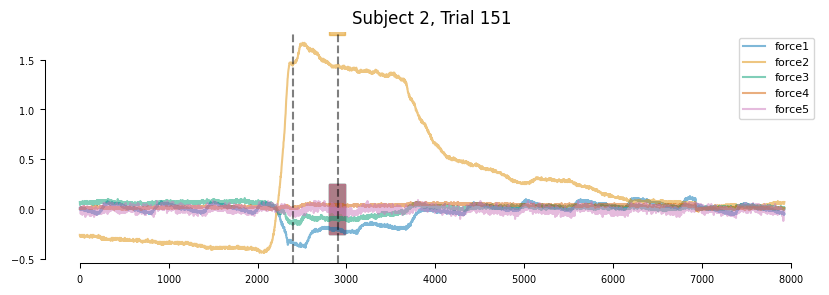

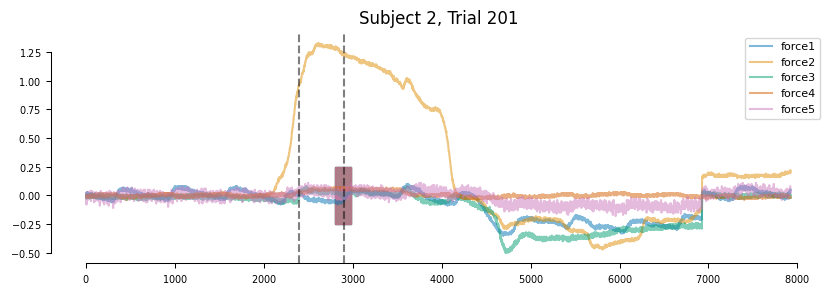

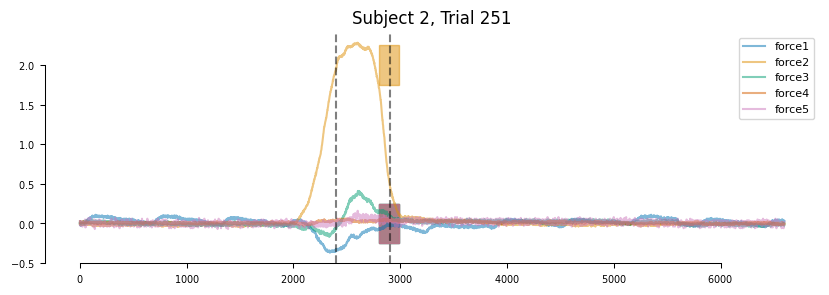

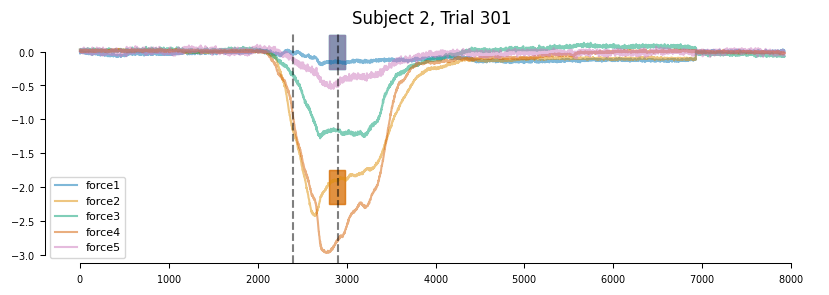

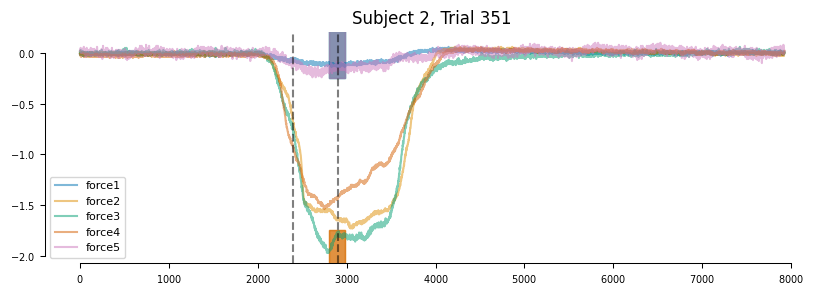

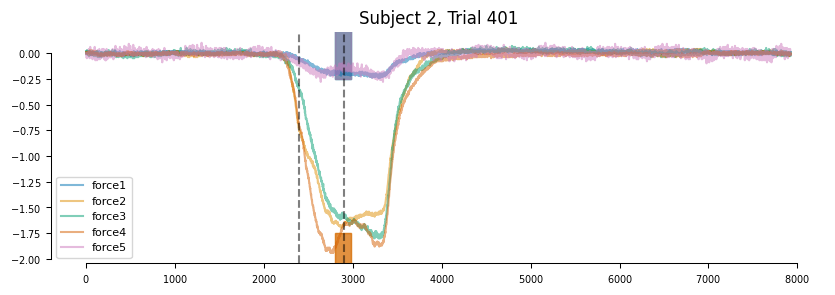

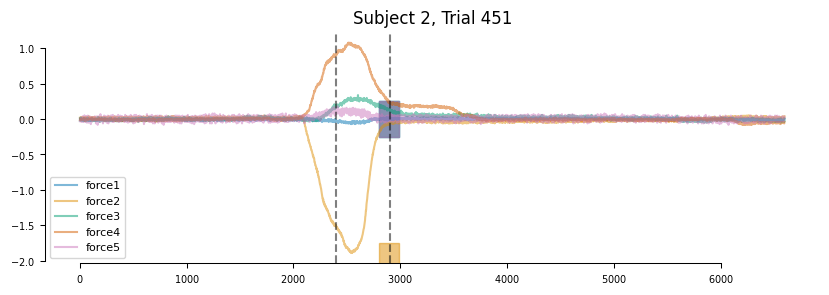

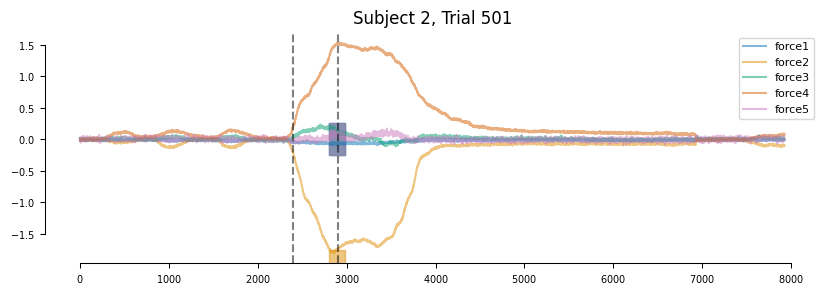

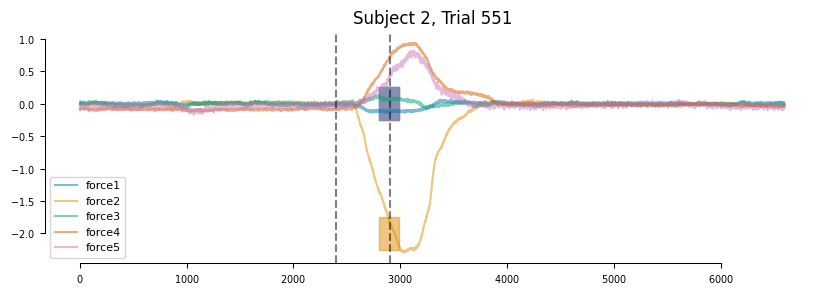

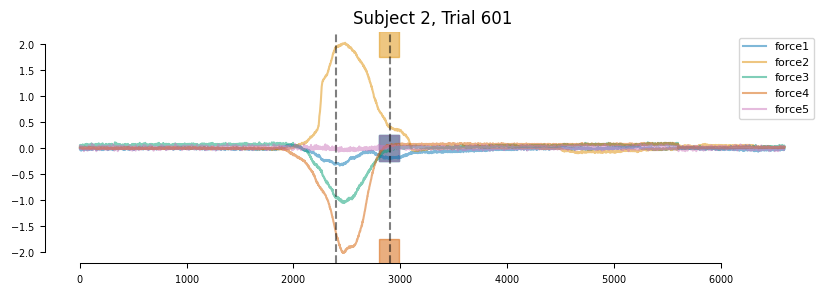

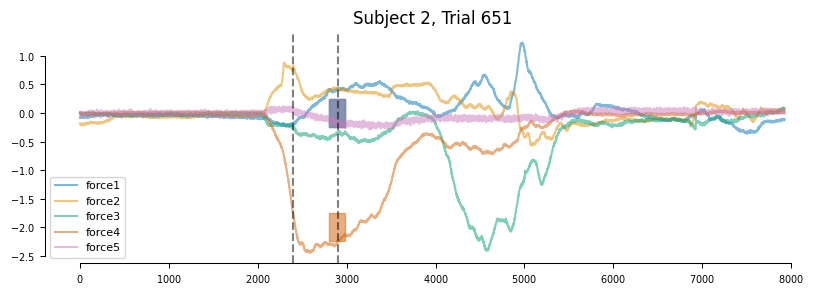

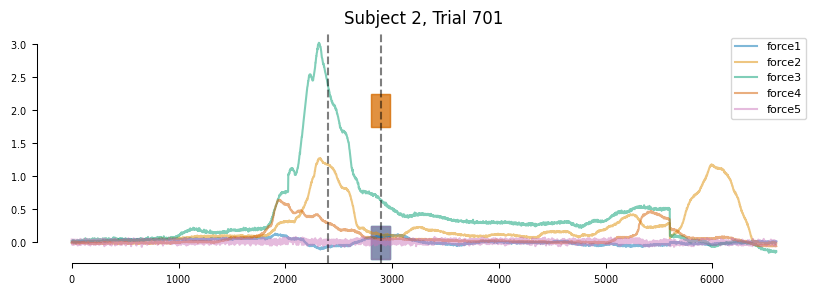

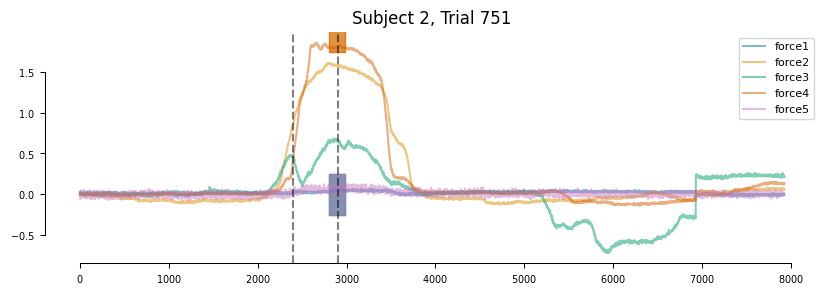

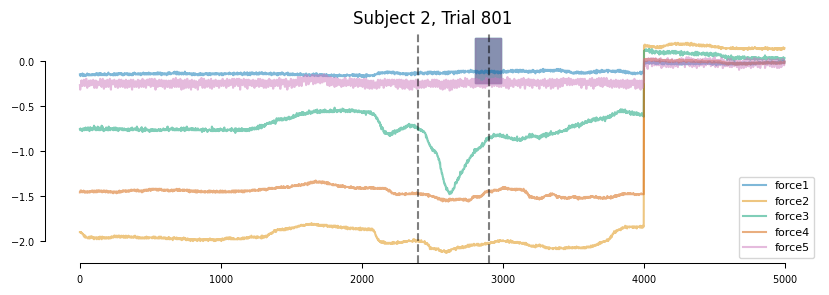

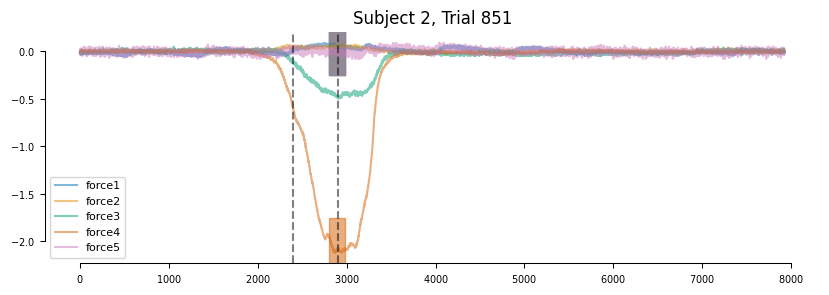

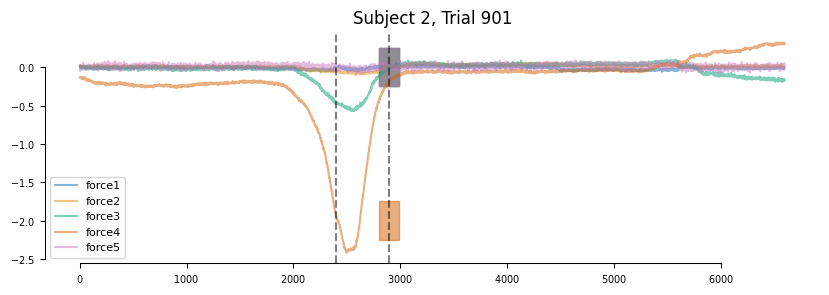

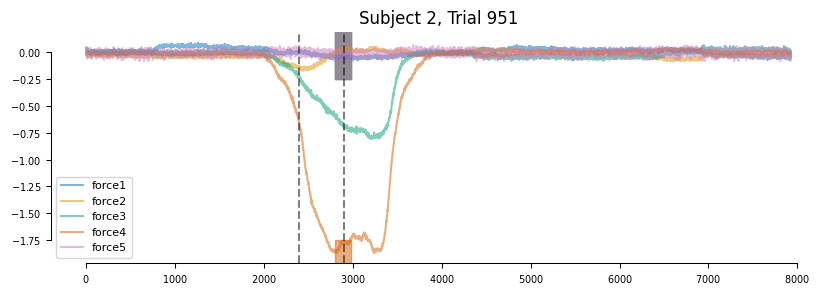

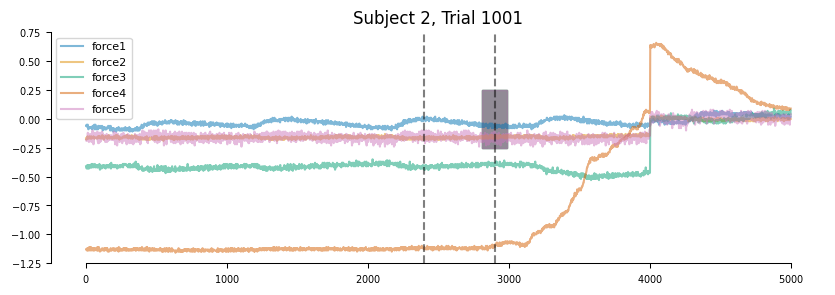

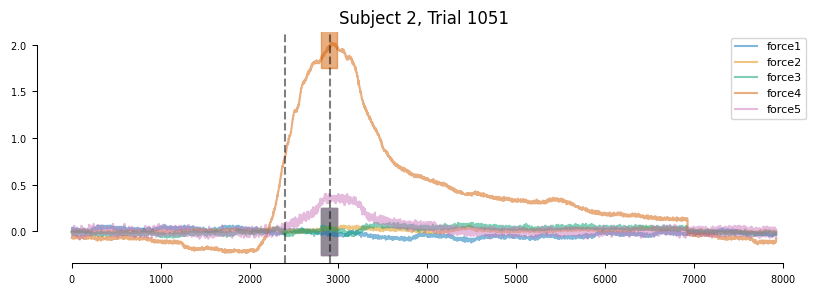

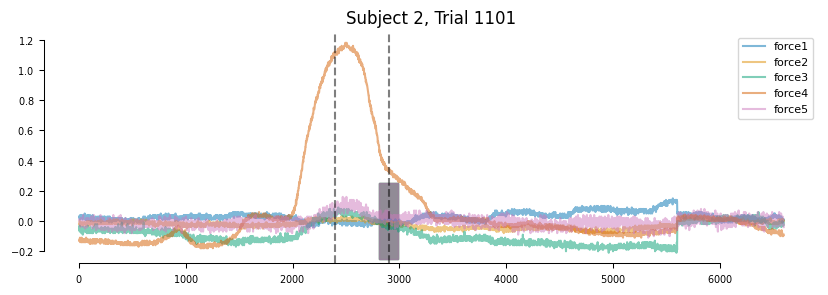

In [12]:
trials_to_plot = list(range(1, 140 * 8, 50))

for trial in trials_to_plot:
    plot_forces(subjs_force_train, sub_num = 2, trial_num = trial)

In [ ]:
subjs_force_train.columns

Index(['state', 'time', 'subNum', 'BN', 'TN', 'targetForce1', 'targetForce2',
       'targetForce3', 'targetForce4', 'targetForce5', 'endForce1',
       'endForce2', 'endForce3', 'endForce4', 'endForce5', 'TotalTrialNum',
       'trialPoint', 'trialCorr', 'trialErrorType', 'Force_Number',
       'Force_Value'],
      dtype='object')

In [6]:
# subjs_force_train.to_csv(utils.path_misc+'subjs_force_train.csv', index = False, sep = '\t')
subjs_force_train = pd.read_csv(utils.path_misc+'subjs_force_train.csv', sep = '\t')

In [7]:
subjs_force_train

,state,time,subNum,BN,TN,trial_num_within_chord,chord,block_type,num_targets,targetForce1,...,endForce1,endForce2,endForce3,endForce4,endForce5,TotalTrialNum,trialCorr,trialErrorType,Force_Number,Force_Value
0,2.0,2.0,4,7,1,1,-^---,unpurturbed,1,0.0,...,-0.415,3.344,-0.638,-0.139,-0.029,421,1,0,force1,-0.04
1,2.0,4.0,4,7,1,1,-^---,unpurturbed,1,0.0,...,-0.415,3.344,-0.638,-0.139,-0.029,421,1,0,force1,-0.02
2,2.0,6.0,4,7,1,1,-^---,unpurturbed,1,0.0,...,-0.415,3.344,-0.638,-0.139,-0.029,421,1,0,force1,-0.04
3,2.0,8.0,4,7,1,1,-^---,unpurturbed,1,0.0,...,-0.415,3.344,-0.638,-0.139,-0.029,421,1,0,force1,-0.03
4,2.0,10.0,4,7,1,1,-^---,unpurturbed,1,0.0,...,-0.415,3.344,-0.638,-0.139,-0.029,421,1,0,force1,-0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84691030,6.0,7916.0,3,3,20,20,-v-^-,unpurturbed,2,0.0,...,0.257,-1.923,0.017,2.292,0.013,160,1,0,force5,0.02
84691031,6.0,7918.0,3,3,20,20,-v-^-,unpurturbed,2,0.0,...,0.257,-1.923,0.017,2.292,0.013,160,1,0,force5,-0.02
84691032,6.0,7920.0,3,3,20,20,-v-^-,unpurturbed,2,0.0,...,0.257,-1.923,0.017,2.292,0.013,160,1,0,force5,-0.01
84691033,6.0,7922.0,3,3,20,20,-v-^-,unpurturbed,2,0.0,...,0.257,-1.923,0.017,2.292,0.013,160,1,0,force5,-0.03


In [ ]:
subjs_force_train

,state,time,subNum,BN,TN,targetForce1,targetForce2,targetForce3,targetForce4,targetForce5,...,endForce2,endForce3,endForce4,endForce5,TotalTrialNum,trialPoint,trialCorr,trialErrorType,Force_Number,Force_Value
0,2.0,0.0,1,39,1,2.0,-1.0,-2.0,1.5,-1.0,...,-1.051,-1.270,1.275,-1.445,761,4.216,1,0,force1,-0.08
1,2.0,2.0,1,39,1,2.0,-1.0,-2.0,1.5,-1.0,...,-1.051,-1.270,1.275,-1.445,761,4.216,1,0,force1,-0.06
2,2.0,4.0,1,39,1,2.0,-1.0,-2.0,1.5,-1.0,...,-1.051,-1.270,1.275,-1.445,761,4.216,1,0,force1,-0.08
3,2.0,6.0,1,39,1,2.0,-1.0,-2.0,1.5,-1.0,...,-1.051,-1.270,1.275,-1.445,761,4.216,1,0,force1,-0.06
4,2.0,8.0,1,39,1,2.0,-1.0,-2.0,1.5,-1.0,...,-1.051,-1.270,1.275,-1.445,761,4.216,1,0,force1,-0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47027510,6.0,7916.0,1,34,20,2.0,-1.0,-2.0,1.5,-1.0,...,-0.827,-1.586,1.069,-0.876,680,4.628,1,0,force5,-0.01
47027511,6.0,7918.0,1,34,20,2.0,-1.0,-2.0,1.5,-1.0,...,-0.827,-1.586,1.069,-0.876,680,4.628,1,0,force5,0.08
47027512,6.0,7920.0,1,34,20,2.0,-1.0,-2.0,1.5,-1.0,...,-0.827,-1.586,1.069,-0.876,680,4.628,1,0,force5,0.13
47027513,6.0,7922.0,1,34,20,2.0,-1.0,-2.0,1.5,-1.0,...,-0.827,-1.586,1.069,-0.876,680,4.628,1,0,force5,0.09


In [8]:
# smooth forces with a window of 50 ms 
subjs_force_train['Force_Value_Smooth'] = subjs_force_train.groupby(['subNum', 'TotalTrialNum', 'Force_Number'])['Force_Value'].transform(lambda x: x.rolling(window=25, min_periods=1, center=True).mean())

In [9]:
# extract forces between time 2200 ms (before go cue) and 2925 ms (after sampling time)
forces = subjs_force_train[(subjs_force_train['time'] >= 2200) & (subjs_force_train['time'] <= 2925)].copy()

In [11]:
forces.columns

Index(['state', 'time', 'subNum', 'BN', 'TN', 'trial_num_within_chord',
       'chord', 'block_type', 'num_targets', 'targetForce1', 'targetForce2',
       'targetForce3', 'targetForce4', 'targetForce5', 'endForce1',
       'endForce2', 'endForce3', 'endForce4', 'endForce5', 'TotalTrialNum',
       'trialCorr', 'trialErrorType', 'Force_Number', 'Force_Value',
       'Force_Value_Smooth'],
      dtype='str')

In [12]:
forces['targetForce5'].unique()

array([0.])

In [13]:
def plot_forces_smooth(subjs_forces, sub_num, trial_num):
    plt.figure(figsize=(8,3))
    x = subjs_forces[(subjs_forces['subNum'] == sub_num) & (subjs_forces['TotalTrialNum'] == trial_num)]
    
    for i, (force, data) in enumerate(x.groupby('Force_Number')):
        plt.plot(data['time'], data['Force_Value_Smooth'], label = force,
                 color = sns.color_palette('colorblind')[i], alpha = 0.5)
    
    
    plt.axvline(2400, color = 'black', linestyle = '--', alpha = 0.5) # go cue 
    plt.axvline(2900, color = 'black', linestyle = '--', alpha = 0.5) # sampling time


    target_cols = [f"targetForce{finger}" for finger in fingers]
    target_vals = x[target_cols].iloc[0].to_numpy(dtype=float)


    ax = plt.gca()

    rec_height = 0.5
    for finger in fingers:
        ax.add_patch(Rectangle((2900 - 25, target_vals[int(finger)-1]- (rec_height/2)), 
                            50, rec_height, color = sns.color_palette('colorblind')[int(finger)-1],alpha=0.5))


    plt.title(f'Subject {sub_num}, Trial {trial_num}')
    plt.ylim(-3, 3)
    plt.legend()
    sns.despine(trim = True)

    plt.show()
    

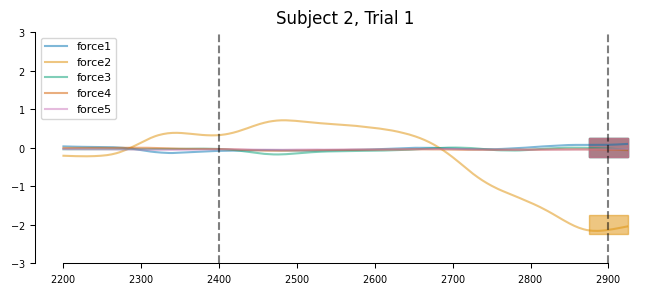

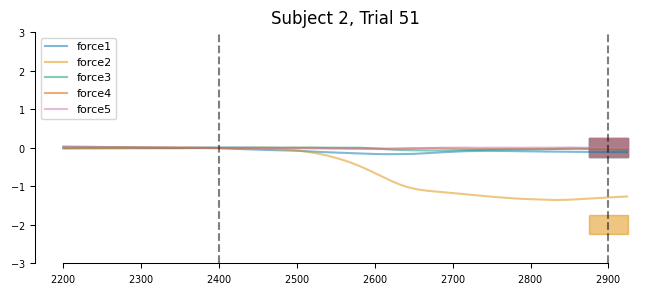

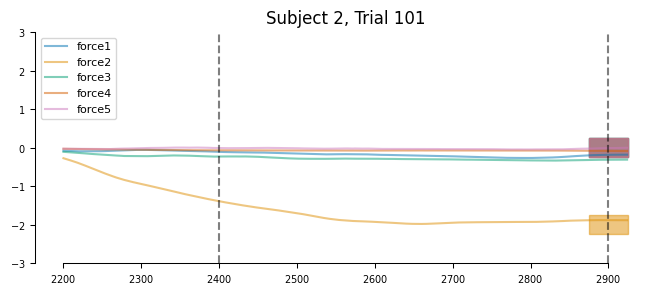

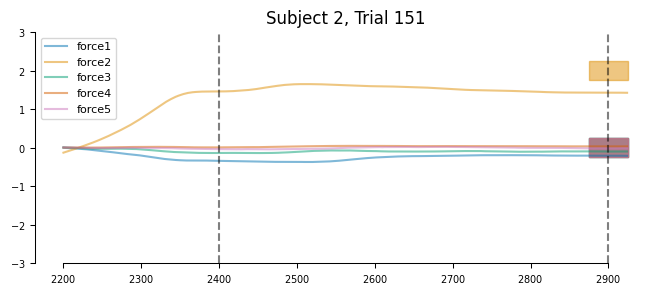

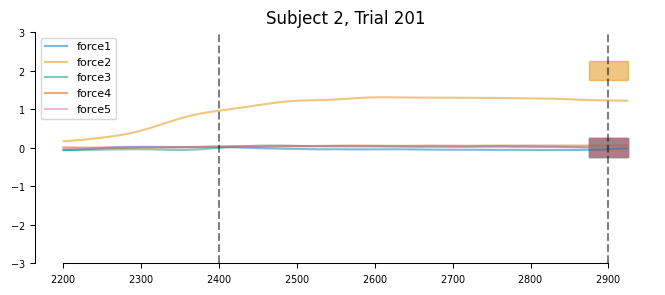

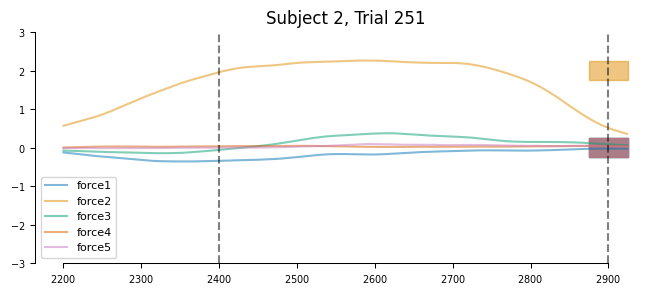

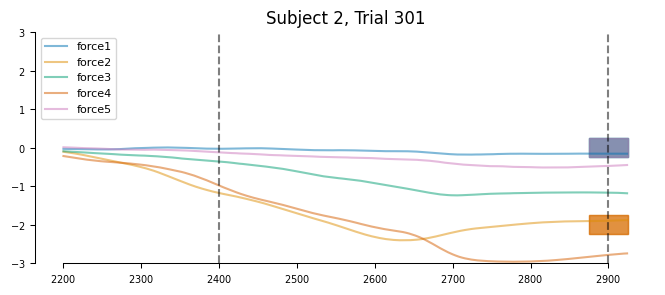

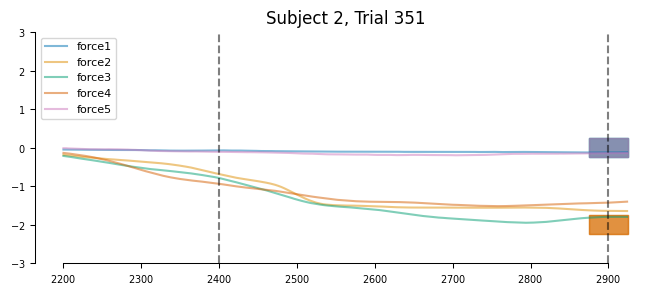

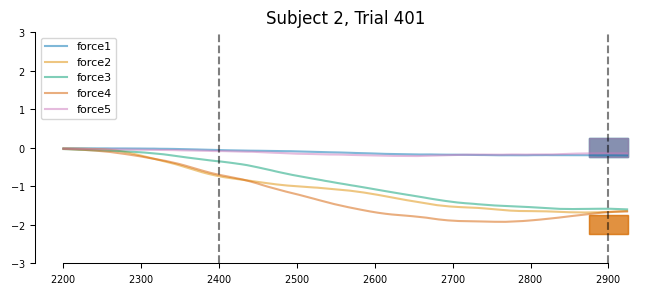

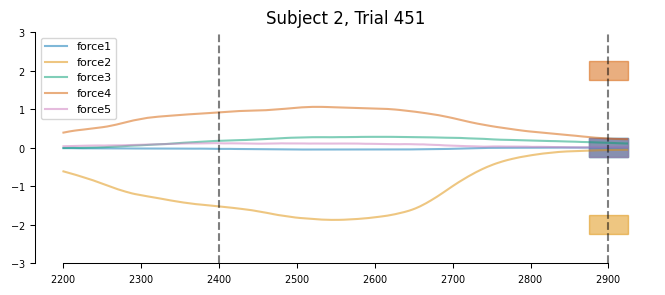

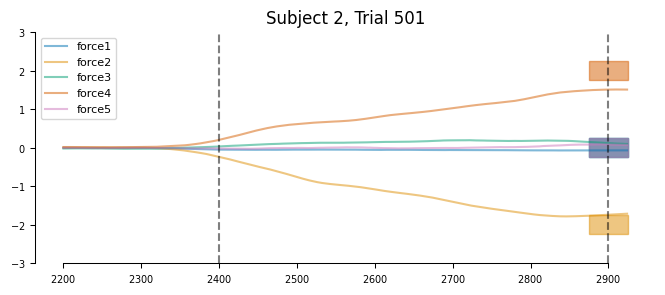

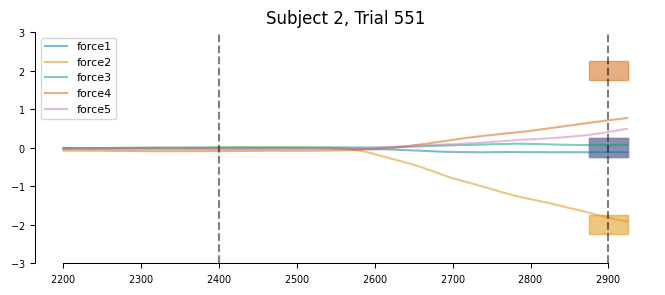

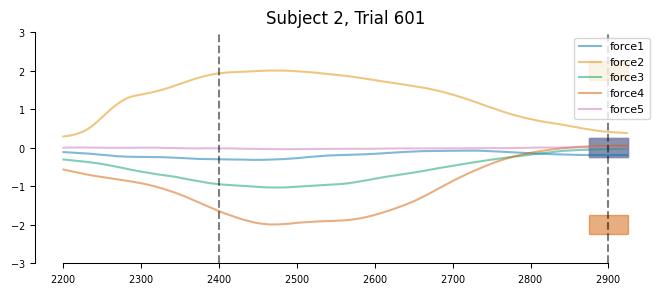

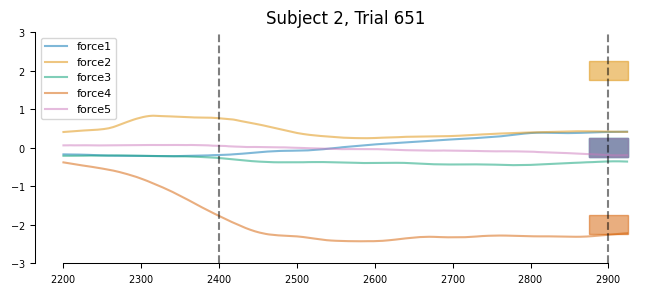

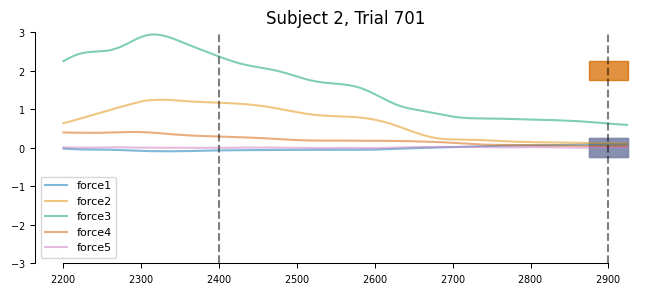

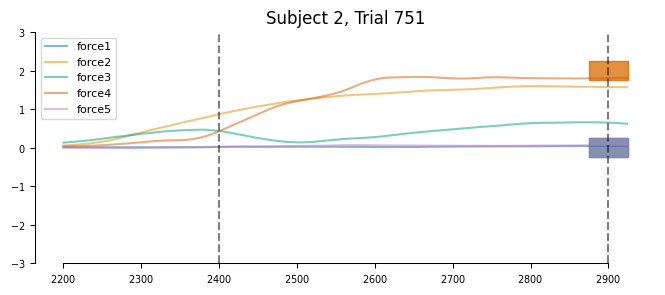

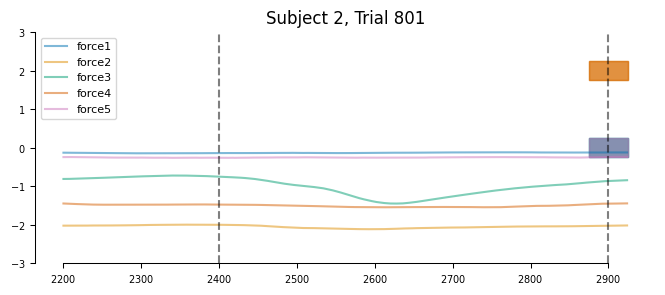

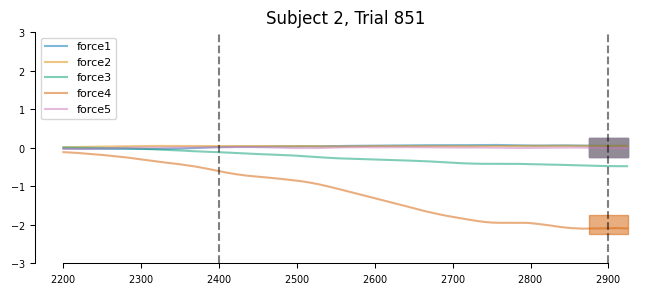

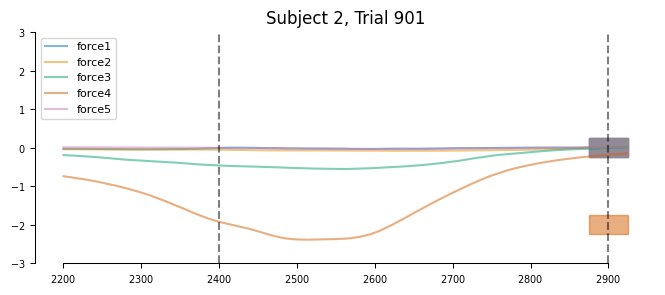

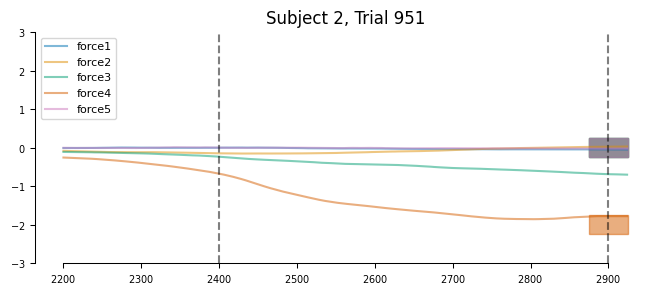

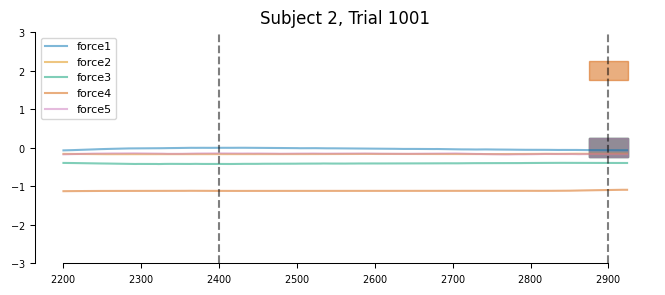

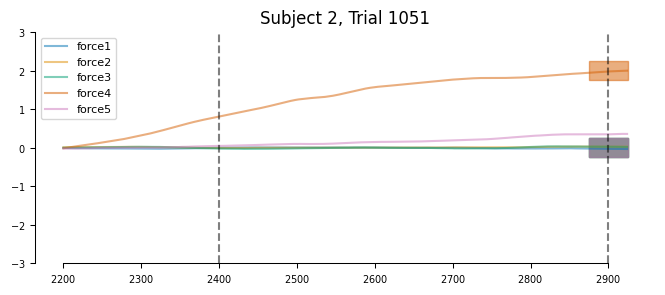

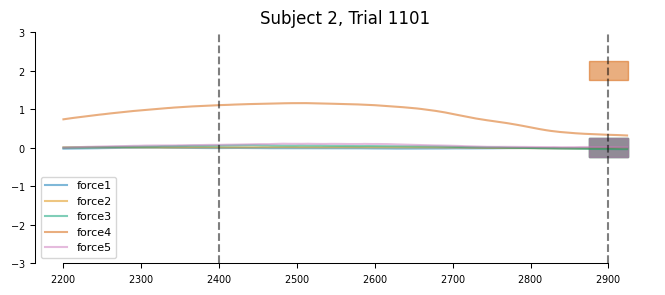

In [41]:
trials_to_plot = list(range(1, 8 * 140, 50))

for trial in trials_to_plot:
    plot_forces_smooth(forces, sub_num = 2, trial_num = trial)

In [118]:
def plot_forces_smooth_average_across_subjects(subjs_forces, chord):
    subjs_forces = subjs_forces[subjs_forces['chord'] == chord].copy()
    forces_correct = utils.remove_error_trials(subjs_forces)
    target_cols = [f"targetForce{finger}" for finger in fingers]
    target_vals = forces_correct[target_cols].iloc[0].to_numpy(dtype=float)

    grouped_forces = forces_correct.groupby(['subNum', 'Force_Number', 'time']).agg({
        'Force_Value_Smooth': 'median'
    }).reset_index()
    

    # avg_forces = forces_correct.groupby(['Force_Number', 'time'])['Force_Value_Smooth'].mean().reset_index()

    plt.figure(figsize=(3,3))   

    # Map for force number to finger label
    force_label_map = {"force2": "index", "force4": "ring"}
    # Assign distinct colors for force2 and force4 using maximally separated colors in colorblind palette
    colorblind_palette = sns.color_palette('colorblind')
    color_order = {
        "force2": 0,  # blue (palette index 0)
        "force4": 1   # orange (palette index 1)
    }

    for force, data in grouped_forces.groupby('Force_Number'):
        if force not in ['force2', 'force4']:
            continue
        label = force_label_map.get(force, force)
        color_idx = color_order[force]
        sns.lineplot(
            data=data,
            x='time',
            y='Force_Value_Smooth',
            label=label,
            color=colorblind_palette[color_idx],
            alpha=0.5,
            errorbar='se'
        )
        ax = plt.gca()
        rec_height = 0.5
        finger = force.split('force')[1]
        if target_vals[int(finger)-1] != 0:
            ax.add_patch(Rectangle(
                (2900 - 25, target_vals[int(finger)-1]- (rec_height/2)), 
                50, rec_height, 
                color=colorblind_palette[color_idx],
                alpha=0.5
            ))
    plt.axvline(2400, color = 'black', linestyle = '--', alpha = 0.5) # go cue
    plt.axvline(2900, color = 'black', linestyle = '--', alpha = 0.5) # sampling time

    rec_height = 0.5

    plt.title(f'Chord {chord}')
    plt.ylim(-2.5, 2.5)
    plt.xlabel('Time (ms)')
    plt.ylabel('Force (N)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine(trim = True)
    # plt.savefig(f'{path_figs}subjs_forces/sub{sub_num}_trials_{trial_bin*100}_{(trial_bin+1)*100}_avg_forces.pdf', dpi = 300, bbox_inches='tight')
    plt.savefig(f'{path_figs}_chord_{chord}_avg_forces.pdf', dpi = 300, bbox_inches='tight')
    plt.show()


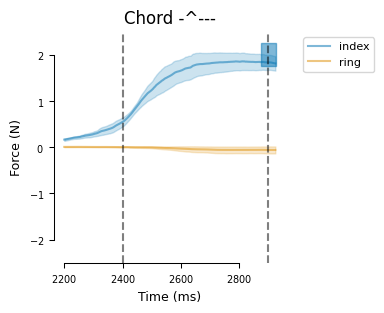

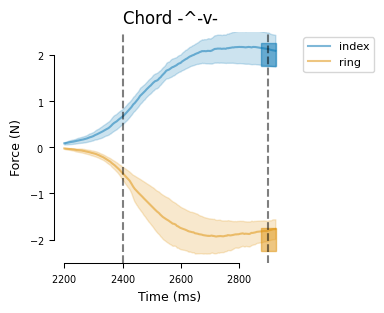

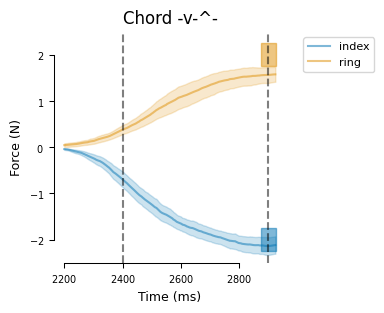

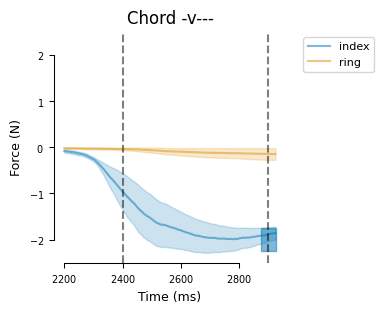

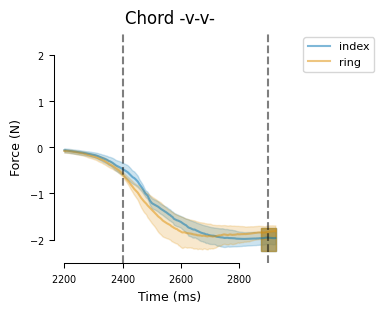

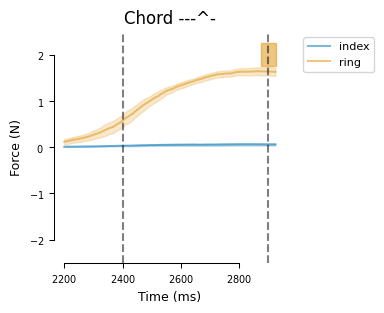

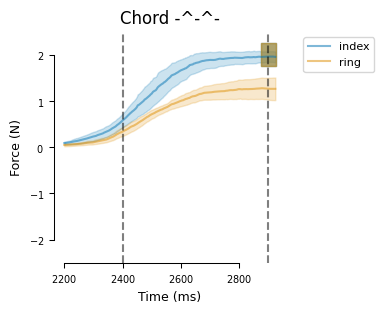

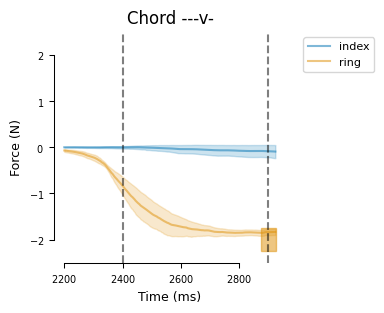

In [119]:
all_chords = subjs_force_train['chord'].unique()
for chord in all_chords:
    plot_forces_smooth_average_across_subjects(forces, chord)

In [ ]:
forces_wide = forces.pivot_table(index=[
    'subNum', 'BN' , 'TN', 'targetForce1', 'targetForce2', 'targetForce3', 'targetForce4', 'targetForce5',
    'endForce1', 'endForce2', 'endForce3', 'endForce4', 'endForce5',
    'TotalTrialNum', 'trialPoint', 'trialCorr', 'trialErrorType'], columns = ['Force_Number', 'time'], 
    values = 'Force_Value_Smooth').reset_index()


In [ ]:
# convert MultiIndex columns to single level
forces_wide.columns = [''.join(map(str, col)).strip() for col in forces_wide.columns.values]
force_cols = [col for col in forces_wide.columns if col.startswith('force')]
new_names = {old: f'force_{i+1}' for i, old in enumerate(force_cols)}
forces_wide.rename(columns=new_names, inplace=True)
forces_wide.to_csv(utils.path_misc+'forces_wide.csv', index = False)

In [ ]:
forces_wide.columns

Index(['subNum', 'BN', 'TN', 'targetForce1', 'targetForce2', 'targetForce3',
       'targetForce4', 'targetForce5', 'endForce1', 'endForce2',
       ...
       'force_1806', 'force_1807', 'force_1808', 'force_1809', 'force_1810',
       'force_1811', 'force_1812', 'force_1813', 'force_1814', 'force_1815'],
      dtype='object', length=1832)